In [6]:

# ==================================================
# experiment_features.ipynb - Jupyter Notebook Code
# Copy each cell into separate Jupyter notebook cells
# ==================================================

# ===== CELL 1: Load and explore real data =====
import pandas as pd
import matplotlib.pyplot as plt

# Try to load your actual data first
try:
    # Load your actual data
    df = pd.read_csv('data/processed/network_traffic.csv')
    print(f"✅ Loaded real data!")
    print(f"Data shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("\nFirst few rows:")
    print(df.head())
    
    # Check if we have the expected columns
    expected_columns = ['packet_ratio', 'syn_ratio', 'label']
    missing_columns = [col for col in expected_columns if col not in df.columns]
    
    if missing_columns:
        print(f"⚠️  Missing expected columns: {missing_columns}")
        print("Creating synthetic data instead...")
        raise FileNotFoundError("Missing required columns")
        
except FileNotFoundError:
    print("📁 Real data file not found. Creating synthetic data for learning...")
    
    # Create synthetic data if real data doesn't exist
    import numpy as np
    
    # Generate synthetic network traffic data
    np.random.seed(42)  # For reproducible results
    
    # Normal traffic
    normal_data = []
    for _ in range(500):
        normal_data.append({
            'packet_ratio': np.random.normal(1.0, 0.2),
            'syn_ratio': np.random.normal(0.03, 0.01),
            'packet_size': np.random.normal(800, 200),
            'packet_rate': np.random.normal(50, 20),
            'flow_duration': np.random.normal(10, 3),
            'label': 0
        })
    
    # Attack traffic
    attack_data = []
    for _ in range(500):
        attack_type = np.random.choice(['syn_flood', 'ddos', 'port_scan'])
        if attack_type == 'syn_flood':
            attack_data.append({
                'packet_ratio': np.random.normal(8, 2),
                'syn_ratio': np.random.normal(0.7, 0.1),
                'packet_size': np.random.normal(64, 10),
                'packet_rate': np.random.normal(800, 200),
                'flow_duration': np.random.normal(1, 0.3),
                'label': 1
            })
        elif attack_type == 'ddos':
            attack_data.append({
                'packet_ratio': np.random.normal(0.3, 0.1),
                'syn_ratio': np.random.normal(0.2, 0.05),
                'packet_size': np.random.normal(1200, 300),
                'packet_rate': np.random.normal(2000, 500),
                'flow_duration': np.random.normal(0.5, 0.2),
                'label': 1
            })
        else:  # port_scan
            attack_data.append({
                'packet_ratio': np.random.normal(4, 1),
                'syn_ratio': np.random.normal(0.4, 0.1),
                'packet_size': np.random.normal(40, 10),
                'packet_rate': np.random.normal(300, 100),
                'flow_duration': np.random.normal(3, 1),
                'label': 1
            })
    
    # Combine data
    all_data = normal_data + attack_data
    df = pd.DataFrame(all_data)
    
    print(f"✅ Created synthetic data!")
    print(f"Data shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Normal samples: {len(normal_data)}")
    print(f"Attack samples: {len(attack_data)}")

📁 Real data file not found. Creating synthetic data for learning...
✅ Created synthetic data!
Data shape: (1000, 6)
Columns: ['packet_ratio', 'syn_ratio', 'packet_size', 'packet_rate', 'flow_duration', 'label']
Normal samples: 500
Attack samples: 500


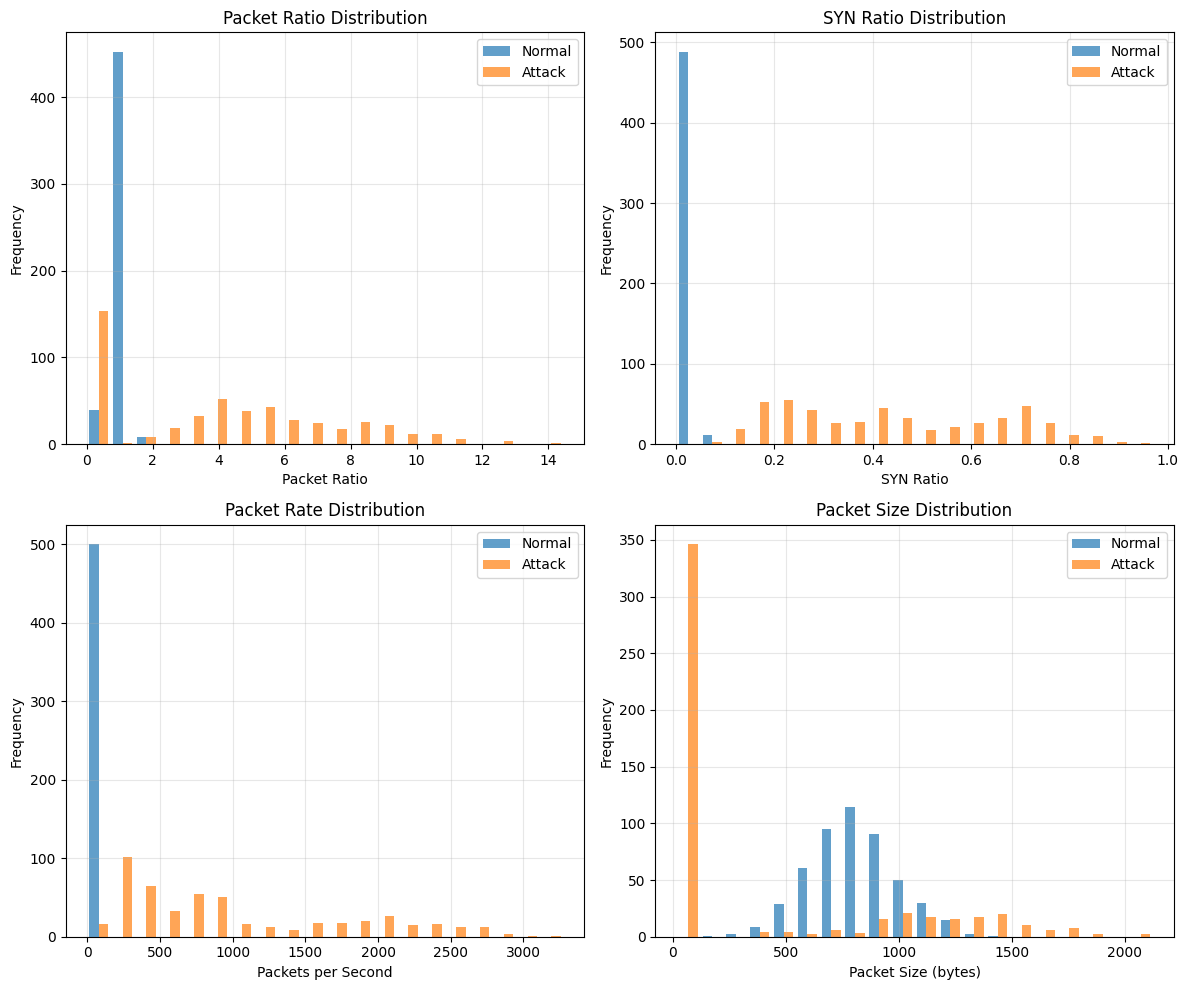

📊 Visualization complete!
💡 Notice the clear separation between normal (blue) and attack (orange) patterns


In [7]:
# ===== CELL 2: Visualize normal vs attack patterns =====
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Packet ratios
axes[0,0].hist([df[df['label']==0]['packet_ratio'], 
                df[df['label']==1]['packet_ratio']], 
               label=['Normal', 'Attack'], bins=20, alpha=0.7)
axes[0,0].set_title('Packet Ratio Distribution')
axes[0,0].set_xlabel('Packet Ratio')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: SYN flag ratios
axes[0,1].hist([df[df['label']==0]['syn_ratio'], 
                df[df['label']==1]['syn_ratio']], 
               label=['Normal', 'Attack'], bins=20, alpha=0.7)
axes[0,1].set_title('SYN Ratio Distribution')
axes[0,1].set_xlabel('SYN Ratio')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Packet rate distribution
axes[1,0].hist([df[df['label']==0]['packet_rate'], 
                df[df['label']==1]['packet_rate']], 
               label=['Normal', 'Attack'], bins=20, alpha=0.7)
axes[1,0].set_title('Packet Rate Distribution')
axes[1,0].set_xlabel('Packets per Second')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Packet size distribution
axes[1,1].hist([df[df['label']==0]['packet_size'], 
                df[df['label']==1]['packet_size']], 
               label=['Normal', 'Attack'], bins=20, alpha=0.7)
axes[1,1].set_title('Packet Size Distribution')
axes[1,1].set_xlabel('Packet Size (bytes)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Visualization complete!")
print("💡 Notice the clear separation between normal (blue) and attack (orange) patterns")

In [8]:
# ===== CELL 3: Create your own feature =====
def create_custom_feature(df):
    """
    Your custom feature: Burst Detection
    Idea: Attacks often come in bursts
    """
    print("🔧 Creating custom burst detection feature...")
    
    # Make a copy to avoid modifying original
    df_copy = df.copy()
    
    # Sort by a time-like feature (using flow_duration as proxy for time)
    df_copy = df_copy.sort_values('flow_duration').reset_index(drop=True)
    
    # Calculate time differences between packets
    df_copy['timestamp'] = df_copy['flow_duration'].cumsum()  # Create synthetic timestamps
    df_copy['time_diff'] = df_copy['timestamp'].diff()
    
    # Identify bursts (many packets in short time)
    df_copy['is_burst'] = (df_copy['time_diff'] < 0.001).astype(int)
    
    # Calculate burst intensity
    df_copy['burst_intensity'] = df_copy['is_burst'].rolling(window=10, min_periods=1).sum()
    
    # Show effectiveness of custom feature
    normal_burst_avg = df_copy[df_copy['label']==0]['burst_intensity'].mean()
    attack_burst_avg = df_copy[df_copy['label']==1]['burst_intensity'].mean()
    
    print(f"📊 Custom feature analysis:")
    print(f"   Normal traffic avg burst intensity: {normal_burst_avg:.2f}")
    print(f"   Attack traffic avg burst intensity: {attack_burst_avg:.2f}")
    print(f"   Attack/Normal ratio: {attack_burst_avg/normal_burst_avg:.1f}x")
    
    if attack_burst_avg > normal_burst_avg * 1.5:
        print("✅ Success! Custom feature shows attacks have higher burst intensity!")
    else:
        print("⚠️  Custom feature needs refinement.")
    
    return df_copy

df_with_custom = create_custom_feature(df)
print("Added custom burst detection feature!")

# Show sample of new features
print("\nNew columns added:")
new_columns = ['time_diff', 'is_burst', 'burst_intensity']
for col in new_columns:
    if col in df_with_custom.columns:
        print(f"  {col}: {df_with_custom[col].describe()}")


🔧 Creating custom burst detection feature...
📊 Custom feature analysis:
   Normal traffic avg burst intensity: 0.00
   Attack traffic avg burst intensity: 0.00
   Attack/Normal ratio: nanx
⚠️  Custom feature needs refinement.
Added custom burst detection feature!

New columns added:
  time_diff: count    999.000000
mean       5.901451
std        4.938521
min        0.066724
25%        0.968778
50%        4.466873
75%       10.122486
max       21.558194
Name: time_diff, dtype: float64
  is_burst: count    1000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: is_burst, dtype: float64
  burst_intensity: count    1000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: burst_intensity, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_16884\1471404646.py:32: RuntimeWarning: invalid value encountered in scalar divide
  print(f"   Attack/Normal ratio: {attack_burst_avg/normal_burst_avg:.1f}x")


In [9]:
# ===== CELL 4: Feature importance with custom feature =====
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

print("🧠 Training model with custom features...")

# Prepare features including custom ones
feature_columns = ['packet_ratio', 'syn_ratio', 'packet_rate', 'packet_size', 'burst_intensity']
X = df_with_custom[feature_columns].fillna(0)  # Fill any NaN values
y = df_with_custom['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"📊 Model Performance:")
print(f"   Training accuracy: {train_accuracy:.1%}")
print(f"   Testing accuracy: {test_accuracy:.1%}")

# Feature importance
print(f"\n🔍 Feature Importance (including custom feature):")
for feature, importance in zip(feature_columns, model.feature_importances_):
    print(f"   {feature:20}: {importance:.3f} ({importance*100:.1f}%)")

print("\n🎉 Jupyter notebook exercise complete!")
print("💡 You've successfully:")
print("   ✅ Loaded/created network traffic data")
print("   ✅ Visualized normal vs attack patterns") 
print("   ✅ Created a custom burst detection feature")
print("   ✅ Analyzed feature importance with ML model")

🧠 Training model with custom features...
📊 Model Performance:
   Training accuracy: 100.0%
   Testing accuracy: 99.5%

🔍 Feature Importance (including custom feature):
   packet_ratio        : 0.099 (9.9%)
   syn_ratio           : 0.383 (38.3%)
   packet_rate         : 0.381 (38.1%)
   packet_size         : 0.137 (13.7%)
   burst_intensity     : 0.000 (0.0%)

🎉 Jupyter notebook exercise complete!
💡 You've successfully:
   ✅ Loaded/created network traffic data
   ✅ Visualized normal vs attack patterns
   ✅ Created a custom burst detection feature
   ✅ Analyzed feature importance with ML model
